# VQBR Step-by-Step Tutorial
This notebook reproduces the logic of `src/vqbr/vqbr.py` directly, without importing from the `vqbr` module.
All cells are plain top-level code so you can inspect and debug each intermediate value.

## 0) Imports

In [1]:
# !pip install qiskit_aer -q

In [2]:
import numpy as np
from scipy.optimize import minimize
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Statevector, Operator, SparsePauliOp
import matplotlib.pyplot as plt

try:
    from qiskit.circuit.library import efficient_su2
    has_efficient_su2 = True
except Exception:
    from qiskit.circuit.library import EfficientSU2
    has_efficient_su2 = False

from qiskit_aer import AerSimulator

np.set_printoptions(precision=6, suppress=True)


## 1) Hyperparameters and Data

In [3]:
random_state = 123
rng = np.random.default_rng(random_state)

# Measurement-based estimator knobs
shots = 10000
use_shot_noise = False
print_loss_every = 1  # print loss every N objective evaluations (set 0 to disable)

# Single-long optimizer budget knob
optimizer = "COBYLA"
max_optimizer_iterations = 200
cobyla_tol = 1e-08  # COBYLA trust-region tolerance

# Ansatz knobs
reps = 2
su2_gates = ("ry", 'x')
entanglement = "linear"

# Objective knobs
eps = 1e-12
loss = "log_ratio"

# Backend knobs
prefer_gpu = True
require_gpu = False

# Synthetic dataset config (aligned with script/exp/synthetic_experiemnt.py)
n_samples_total = 200
n_features = 8
noise_std = 0.1
w_true_std = 1.0

prior_ratio = 0.2
train_ratio = 0.6
test_ratio = 0.2
seed = int(random_state)

# 1) Generate synthetic data (script-style)
X_full = rng.standard_normal(size=(n_samples_total, n_features))
true_w = rng.normal(0.0, w_true_std, size=n_features)
y_full = X_full @ true_w + rng.normal(0.0, noise_std, size=n_samples_total)

# 2) Split into prior/train/test
ratio_sum = float(prior_ratio + train_ratio + test_ratio)
if not np.isclose(ratio_sum, 1.0, atol=1e-12):
    raise ValueError(f"Split ratios must sum to 1.0, got {ratio_sum:.12f}.")

perm = np.random.default_rng(seed).permutation(n_samples_total)
n_prior = int(np.floor(prior_ratio * n_samples_total))
n_train = int(np.floor(train_ratio * n_samples_total))
n_test = int(n_samples_total - n_prior - n_train)

if min(n_prior, n_train, n_test) < 1:
    raise ValueError("Invalid split sizes; need non-empty prior/train/test sets.")

prior_idx = perm[:n_prior]
train_idx = perm[n_prior : n_prior + n_train]
test_idx = perm[n_prior + n_train :]

X_prior, y_prior = X_full[prior_idx], y_full[prior_idx]
X_train, y_train = X_full[train_idx], y_full[train_idx]
X_test, y_test = X_full[test_idx], y_full[test_idx]

# 3) Estimate prior (m0, Sigma0, V) from prior split using bootstrap ridge
bootstrap_samples = 64
prior_ridge = 1e-6
prior_sigma_floor = 1e-4
v_floor = 1e-8


def _ridge_solution(Xb, yb, ridge):
    d = int(Xb.shape[1])
    gram = Xb.T @ Xb + float(ridge) * np.eye(d, dtype=float)
    rhs = Xb.T @ yb
    return np.linalg.solve(gram, rhs)


boot_rng = np.random.default_rng(seed + 77_777)
weights = np.zeros((bootstrap_samples, n_features), dtype=float)
for i in range(bootstrap_samples):
    idx = boot_rng.integers(0, X_prior.shape[0], size=X_prior.shape[0])
    weights[i] = _ridge_solution(X_prior[idx], y_prior[idx], ridge=prior_ridge)

m0 = np.mean(weights, axis=0)
sigma_diag = np.var(weights, axis=0, ddof=0)
sigma_diag = np.maximum(sigma_diag, float(prior_sigma_floor))
Sigma0 = np.diag(sigma_diag)

prior_fit_mse = float(np.mean((X_prior @ m0 - y_prior) ** 2))
V = max(prior_fit_mse, float(v_floor))

# 4) Train VQBR on train split (same protocol as script)
X = X_train.copy()
y = y_train.copy()

print("X_full shape:", X_full.shape)
print("split sizes:", {"prior": X_prior.shape[0], "train": X_train.shape[0], "test": X_test.shape[0]})
print("training X shape:", X.shape)
print("training y shape:", y.shape)
print("m0 shape:", m0.shape)
print("Sigma0 shape:", Sigma0.shape)
print("V:", V)
print("optimizer:", optimizer)
print("max_optimizer_iterations:", max_optimizer_iterations)
print("cobyla_tol:", cobyla_tol)
print("shots:", shots)
print("use_shot_noise:", use_shot_noise)
print("loss:", loss)
print("print_loss_every:", print_loss_every)



X_full shape: (200, 8)
split sizes: {'prior': 40, 'train': 120, 'test': 40}
training X shape: (120, 8)
training y shape: (120,)
m0 shape: (8,)
Sigma0 shape: (8, 8)
V: 0.009654054133466589
optimizer: COBYLA
max_optimizer_iterations: 200
cobyla_tol: 1e-08
shots: 10000
use_shot_noise: False
loss: log_ratio
print_loss_every: 1


## 2) Input Validation (mirrors `_validate_and_prepare_inputs`)

In [4]:
X = np.asarray(X, dtype=float)
y = np.asarray(y, dtype=float).reshape(-1)
m0 = np.asarray(m0, dtype=float).reshape(-1)
Sigma0 = np.asarray(Sigma0, dtype=float)

if X.ndim != 2:
    raise ValueError(f"X must be 2D, got shape={X.shape}.")

n_samples, n_features = X.shape
if y.shape[0] != n_samples:
    raise ValueError(f"y must have length {n_samples}, got {y.shape[0]}.")
if m0.shape[0] != n_features:
    raise ValueError(f"m0 must have length {n_features}, got {m0.shape[0]}.")

if Sigma0.ndim == 1:
    if Sigma0.shape[0] != n_features:
        raise ValueError(f"Sigma0 must have length {n_features}, got {Sigma0.shape[0]}.")
    if np.any(Sigma0 <= 0.0):
        raise ValueError("All entries of 1D Sigma0 must be positive.")
    Sigma0_matrix = np.diag(Sigma0.copy())
elif Sigma0.ndim == 2:
    if Sigma0.shape != (n_features, n_features):
        raise ValueError(f"Sigma0 must be ({n_features}, {n_features}), got {Sigma0.shape}.")
    if not np.allclose(Sigma0, Sigma0.T, atol=1e-12):
        raise ValueError("Sigma0 must be symmetric.")
    np.linalg.cholesky(Sigma0)
    Sigma0_matrix = Sigma0.copy()
else:
    raise ValueError("Sigma0 must be either a 1D diagonal vector or a 2D matrix.")

V = float(V)
if V < 0.0:
    raise ValueError("V must be non-negative.")

print("Validation passed.")
print("Sigma0_matrix shape:", Sigma0_matrix.shape)

Validation passed.
Sigma0_matrix shape: (8, 8)


## 3) Dimension Setup and Backend Selection

In [5]:
num_qubits = int(np.ceil(np.log2(n_features)))
state_dim = 2 ** num_qubits

statevector_backend = None
simulator_device = "CPU"
simulator_backend = "statevector_cpu"
simulator_reason = "Using CPU statevector simulator."

if not prefer_gpu:
    simulator_reason = "Using CPU statevector simulator (prefer_gpu=False)."
else:
    if AerSimulator is None:
        simulator_reason = "Using CPU statevector simulator (qiskit-aer unavailable)."
        if require_gpu:
            raise RuntimeError("GPU required but qiskit-aer is unavailable.")
    else:
        available_devices = set()
        if hasattr(AerSimulator, "available_devices"):
            try:
                available_devices = {str(d).strip().upper() for d in AerSimulator.available_devices()}
            except Exception:
                available_devices = set()
        if not available_devices:
            try:
                available_devices = {str(d).strip().upper() for d in AerSimulator().available_devices()}
            except Exception:
                available_devices = set()

        if available_devices and "GPU" not in available_devices:
            simulator_reason = "Using CPU statevector simulator (GPU unavailable)."
            if require_gpu:
                raise RuntimeError("GPU required but no GPU device reported by Aer.")
        else:
            try:
                statevector_backend = AerSimulator(method="statevector", device="GPU")
                simulator_device = "GPU"
                simulator_backend = "AerSimulator(statevector,GPU)"
                simulator_reason = "Using AerSimulator(method='statevector', device='GPU')."
            except Exception:
                simulator_reason = "Using CPU statevector simulator (Aer GPU init failed)."
                if require_gpu:
                    raise RuntimeError("GPU required but Aer GPU initialization failed.")

print("[VQBR] backend=" + simulator_backend + ", device=" + simulator_device + ", reason=" + simulator_reason)
print("num_qubits:", num_qubits)
print("state_dim:", state_dim)

[VQBR] backend=AerSimulator(statevector,GPU), device=GPU, reason=Using AerSimulator(method='statevector', device='GPU').
num_qubits: 3
state_dim: 8


## 4) Precision Matrix, Diagonal Detection, and Padding

In [6]:
eye = np.eye(Sigma0_matrix.shape[0], dtype=float)
precision = np.linalg.solve(Sigma0_matrix, eye)
precision = 0.5 * (precision + precision.T)

precision_diag = np.diag(precision)
off_diag = precision - np.diag(precision_diag)
precision_is_diagonal = bool(np.allclose(off_diag, 0.0, atol=1e-12))

if precision_diag.ndim != 1 or precision_diag.size == 0:
    raise ValueError("precision_diag must be a non-empty 1D vector.")

target_dim = 2 ** int(np.ceil(np.log2(precision_diag.size)))
if precision_diag.size == target_dim:
    precision_diag_padded = precision_diag.copy()
else:
    precision_diag_padded = np.pad(precision_diag, (0, target_dim - precision_diag.size), mode="constant")

print("precision shape:", precision.shape)
print("precision_is_diagonal:", precision_is_diagonal)
print("precision_diag_padded shape:", precision_diag_padded.shape)

precision shape: (8, 8)
precision_is_diagonal: True
precision_diag_padded shape: (8,)


## 5) Build `Ux_i` Gates and Row Norms

In [7]:
row_norms = np.linalg.norm(X, axis=1)
if np.any(row_norms <= 0.0):
    raise ValueError("Each row in X must have non-zero norm for normalized state encoding.")

Uxi_gates = []
for i in range(n_samples):
    vec = np.asarray(X[i], dtype=complex).reshape(-1)
    row_target_dim = 2 ** int(np.ceil(np.log2(vec.size)))
    if vec.size != row_target_dim:
        vec = np.pad(vec, (0, row_target_dim - vec.size), mode="constant")
    vec_norm = np.linalg.norm(vec)
    if vec_norm <= 0.0:
        raise ValueError("State preparation vector norm must be non-zero.")
    vec = vec / vec_norm

    prep = StatePreparation(vec)
    if hasattr(prep, "to_gate"):
        gate = prep.to_gate(label=f"Ux_{i}")
    else:
        gate = prep
    Uxi_gates.append(gate)

# Conditioning diagnostics: poor conditioning + nearly parallel rows make shot-noise training unstable.
gram_diagnostic = X.T @ X + float(V) * precision
gram_cond = float(np.linalg.cond(gram_diagnostic))
X_unit = X / np.linalg.norm(X, axis=1, keepdims=True)
row_cos = X_unit @ X_unit.T
avg_row_cos_offdiag = float((row_cos.sum() - np.trace(row_cos)) / (n_samples * (n_samples - 1)))

print("row_norms:", row_norms)
print("num Ux gates:", len(Uxi_gates))
print("cond(X^T X + V Sigma0^{-1}):", gram_cond)
print("avg pairwise row cosine:", avg_row_cos_offdiag)
if gram_cond > 1e3:
    print("[Warning] Ill-conditioned system: shot-noise can strongly degrade direction recovery.")


row_norms: [2.798876 2.852892 2.940197 4.093699 1.801958 2.117277 3.005642 3.276959
 3.158909 2.001547 2.718069 3.708036 3.535106 1.078114 2.605083 2.466773
 2.615785 2.69921  2.353268 3.274174 2.097705 2.087412 1.810612 3.210497
 3.345613 1.424589 3.506356 2.951079 4.041291 1.296873 3.08037  2.282703
 2.113278 3.069941 3.02431  3.361542 2.254648 2.397051 1.899725 1.787655
 2.895862 4.316115 2.790035 1.891632 3.036698 2.933242 2.481611 2.771417
 3.258577 1.587116 3.10234  2.932702 2.703989 1.931577 4.019353 2.705979
 2.480583 3.33035  2.362954 3.767966 2.277351 2.696107 3.599292 3.441317
 2.165335 2.181996 2.227822 2.940734 1.703239 3.007374 1.60911  2.612936
 1.729489 1.864156 2.879162 2.215571 2.277754 2.994109 3.024399 2.227687
 3.167267 3.335431 2.383403 3.282135 2.645289 3.313894 1.302836 4.016695
 3.296056 1.979666 3.559555 2.474711 3.401616 3.852583 2.212038 3.650675
 2.706767 3.044061 2.75113  1.783658 2.736606 2.314761 3.672593 2.697903
 2.851681 3.88097  2.736285 3.726631 3.0

## 6) Build Prior Gate `Uc` from `c = V * precision @ m0`

In [8]:
c = V * (precision @ m0)
c_norm = float(np.linalg.norm(c))
Uc_gate = None

if c_norm > 0.0:
    c_vec = np.asarray(c, dtype=complex).reshape(-1)
    c_target_dim = 2 ** int(np.ceil(np.log2(c_vec.size)))
    if c_vec.size != c_target_dim:
        c_vec = np.pad(c_vec, (0, c_target_dim - c_vec.size), mode="constant")
    c_vec = c_vec / np.linalg.norm(c_vec)

    prep_c = StatePreparation(c_vec)
    if hasattr(prep_c, "to_gate"):
        Uc_gate = prep_c.to_gate(label="Uc")
    else:
        Uc_gate = prep_c

print("c:", c)
print("c_norm:", c_norm)
print("Uc_gate exists:", Uc_gate is not None)

c: [ 22.797362  21.814128  43.402806  29.121704 -12.193865  27.807163
  -3.100128   1.575812]
c_norm: 68.27500073840329
Uc_gate exists: True


## 7) Build Ansatz and Initial Parameters

In [9]:
if has_efficient_su2:
    ansatz = efficient_su2(
        num_qubits,
        su2_gates=list(su2_gates),
        entanglement=entanglement,
        reps=reps,
    )
else:
    ansatz = EfficientSU2(
        num_qubits,
        su2_gates=list(su2_gates),
        entanglement=entanglement,
        reps=reps,
    )

theta_params = list(ansatz.parameters)
num_params = len(theta_params)
theta_init = 0.01 * rng.standard_normal(num_params)

print(ansatz)
print("num_params:", num_params)
print("theta_init:", theta_init)

     ┌──────────┐┌───┐     ┌──────────┐   ┌───┐              ┌──────────┐»
q_0: ┤ Ry(θ[0]) ├┤ X ├──■──┤ Ry(θ[3]) ├───┤ X ├───────────■──┤ Ry(θ[6]) ├»
     ├──────────┤├───┤┌─┴─┐└──────────┘┌──┴───┴───┐┌───┐┌─┴─┐└──────────┘»
q_1: ┤ Ry(θ[1]) ├┤ X ├┤ X ├─────■──────┤ Ry(θ[4]) ├┤ X ├┤ X ├─────■──────»
     ├──────────┤├───┤└───┘   ┌─┴─┐    ├──────────┤├───┤└───┘   ┌─┴─┐    »
q_2: ┤ Ry(θ[2]) ├┤ X ├────────┤ X ├────┤ Ry(θ[5]) ├┤ X ├────────┤ X ├────»
     └──────────┘└───┘        └───┘    └──────────┘└───┘        └───┘    »
«        ┌───┐         
«q_0: ───┤ X ├─────────
«     ┌──┴───┴───┐┌───┐
«q_1: ┤ Ry(θ[7]) ├┤ X ├
«     ├──────────┤├───┤
«q_2: ┤ Ry(θ[8]) ├┤ X ├
«     └──────────┘└───┘
num_params: 9
theta_init: [-0.014496 -0.025697 -0.000757 -0.022631  0.003029 -0.015262  0.004183
 -0.011855 -0.020519]


## 8) One Full Objective Evaluation (`a_hat`, `c_hat`, `d_hat`, `e_hat`, `h_hat`, `L_tilde`)

This section uses measurement estimators in two modes:
- `use_shot_noise=True`: finite-shot sampling (hardware-like).
- `use_shot_noise=False`: analytic expectation values (infinite-shot debug mode).


In [10]:
# Measurement-based estimators for a_hat, c_hat, d_hat, e_hat
if use_shot_noise and AerSimulator is None:
    raise RuntimeError("qiskit-aer is required for finite-shot estimation.")

sampling_backend = AerSimulator() if use_shot_noise else None
print("estimation mode:", "finite-shot" if use_shot_noise else "analytic (infinite-shot)")

M_pad = np.zeros((state_dim, state_dim), dtype=complex)
M_pad[:n_features, :n_features] = V * precision

# Precompute Pauli decomposition only for dense-precision finite-shot mode.
dense_pauli_terms = None
if (not precision_is_diagonal) and use_shot_noise:
    dense_pauli = SparsePauliOp.from_operator(Operator(M_pad)).simplify(atol=1e-12)
    dense_pauli_terms = []
    for label, coeff in zip(dense_pauli.paulis.to_labels(), dense_pauli.coeffs):
        if abs(coeff) > 1e-12:
            dense_pauli_terms.append((label, complex(coeff)))
    print("dense Pauli terms:", len(dense_pauli_terms))

def run_shot_counts(qc, shots):
    qc_meas = qc.copy()
    qc_meas.measure_all()
    compiled = transpile(qc_meas, sampling_backend, optimization_level=0)
    result = sampling_backend.run(compiled, shots=shots).result()
    counts = result.get_counts(compiled)
    if isinstance(counts, list):
        counts = counts[0]
    total = int(sum(counts.values()))
    if total <= 0:
        raise RuntimeError("No counts returned from sampler backend.")
    return counts, total

def ancilla_p0_exact(qc):
    # Qubit-0 (ancilla) is the least-significant qubit in statevector indexing.
    sv = np.asarray(Statevector.from_instruction(qc).data, dtype=complex)
    probs = np.abs(sv) ** 2
    return float(np.sum(probs[::2]))

def estimate_overlap_shots(Uv_gate, theta_vec, shots):
    qc = QuantumCircuit(1 + num_qubits)
    anc = 0
    work = list(range(1, 1 + num_qubits))

    qc.h(anc)
    qc.x(anc)
    qc.append(Uv_gate.control(1), [anc] + work)
    qc.x(anc)

    theta_bind = {p: float(v) for p, v in zip(theta_params, theta_vec)}
    bound_ansatz = ansatz.assign_parameters(theta_bind, inplace=False)
    qc.append(bound_ansatz.to_gate(label="Utheta").control(1), [anc] + work)
    qc.h(anc)

    if use_shot_noise:
        counts, total = run_shot_counts(qc, shots)
        # Bitstring order is c[n-1]...c[0], so ancilla q0 is rightmost char.
        n0 = sum(cnt for bitstr, cnt in counts.items() if bitstr[-1] == "0")
        p0 = float(n0) / float(total)
    else:
        p0 = ancilla_p0_exact(qc)

    return float(np.clip(2.0 * p0 - 1.0, -1.0, 1.0))

def estimate_d_hat_shots(theta_vec, shots):
    theta_bind = {p: float(v) for p, v in zip(theta_params, theta_vec)}
    bound_ansatz = ansatz.assign_parameters(theta_bind, inplace=False)

    qc = QuantumCircuit(num_qubits)
    qc.compose(bound_ansatz, inplace=True)

    if precision_is_diagonal:
        if use_shot_noise:
            counts, total = run_shot_counts(qc, shots)
            d_hat = 0.0
            for bitstr, cnt in counts.items():
                basis_index = int(bitstr, 2)
                d_hat += float(precision_diag_padded[basis_index]) * float(cnt) / float(total)
            return float(V * d_hat)

        sv = np.asarray(Statevector.from_instruction(qc).data, dtype=complex)
        probs = np.abs(sv) ** 2
        return float(V * np.dot(precision_diag_padded, probs))

    # Dense precision case
    if not use_shot_noise:
        sv = np.asarray(Statevector.from_instruction(qc).data, dtype=complex)
        return float(np.real(np.vdot(sv, M_pad @ sv)))

    if dense_pauli_terms is None:
        raise RuntimeError("Dense precision shot path requires Pauli decomposition terms.")

    d_hat = 0.0
    for label, coeff in dense_pauli_terms:
        qc_term = QuantumCircuit(num_qubits)
        qc_term.compose(bound_ansatz, inplace=True)

        # Basis change for Pauli measurement.
        for q in range(num_qubits):
            pauli_char = label[num_qubits - 1 - q]
            if pauli_char == "X":
                qc_term.h(q)
            elif pauli_char == "Y":
                qc_term.sdg(q)
                qc_term.h(q)

        counts, total = run_shot_counts(qc_term, shots)
        mu_hat = 0.0
        for bitstr, cnt in counts.items():
            parity = 1.0
            for q in range(num_qubits):
                pauli_char = label[num_qubits - 1 - q]
                if pauli_char == "I":
                    continue
                if bitstr[-1 - q] == "1":
                    parity *= -1.0
            mu_hat += parity * float(cnt) / float(total)
        d_hat += float(np.real(coeff)) * mu_hat

    return float(d_hat)

# One full-batch objective evaluation with measurement-based estimators.
theta = theta_init.copy()
batch_indices = np.arange(n_samples, dtype=int)

s = np.array([estimate_overlap_shots(Uxi_gates[i], theta, shots) for i in batch_indices], dtype=float)
r = row_norms[batch_indices]
yb = y[batch_indices]

a_hat = float(np.sum((r * s) ** 2))
c_hat = float(np.sum(yb * (r * s)))

h_hat = 0.0
e_hat = 0.0
if Uc_gate is not None and c_norm > 0.0:
    h_hat = estimate_overlap_shots(Uc_gate, theta, shots)
    e_hat = float(c_norm * h_hat)

d_hat = estimate_d_hat_shots(theta, shots)

denom = a_hat + d_hat + eps
numerator = c_hat + e_hat
if loss == "log_ratio":
    L_tilde = float(np.log(denom) - np.log((numerator * numerator) + eps))
else:
    L_tilde = float(-((numerator * numerator) / denom))

print("a_hat:", a_hat)
print("c_hat:", c_hat)
print("d_hat:", d_hat)
print("e_hat:", e_hat)
print("h_hat:", h_hat)
print("L_tilde:", L_tilde)


estimation mode: analytic (infinite-shot)


a_hat: 129.12757217973976
c_hat: 200.00335896132574
d_hat: 14.214270697529436
e_hat: 22.20373599002689
h_hat: 0.3252103368713366
L_tilde: -5.841987327171373


## 9) Single Long COBYLA Training

We use one COBYLA call on the full-data objective with
`maxiter = max_optimizer_iterations`.


In [11]:
# Objective helper
def compute_batch_loss(theta_vec, batch_indices, scale_to_full=True):
    batch_indices = np.asarray(batch_indices, dtype=int).reshape(-1)
    if batch_indices.size == 0:
        raise ValueError("batch_indices must not be empty.")

    s = np.array([estimate_overlap_shots(Uxi_gates[i], theta_vec, shots) for i in batch_indices], dtype=float)
    r = row_norms[batch_indices]
    yb = y[batch_indices]

    # Scale data terms so a mini-batch approximates the full-data objective.
    scale = float(n_samples / batch_indices.size) if scale_to_full else 1.0
    a_hat = float(scale * np.sum((r * s) ** 2))
    c_hat = float(scale * np.sum(yb * (r * s)))

    h_hat = 0.0
    e_hat = 0.0
    if Uc_gate is not None and c_norm > 0.0:
        h_hat = estimate_overlap_shots(Uc_gate, theta_vec, shots)
        e_hat = float(c_norm * h_hat)

    d_hat = estimate_d_hat_shots(theta_vec, shots)

    denom = a_hat + d_hat + eps
    numerator = c_hat + e_hat
    if loss == "log_ratio":
        L_tilde = float(np.log(denom) - np.log((numerator * numerator) + eps))
    else:
        L_tilde = float(-((numerator * numerator) / denom))

    snapshot = {
        "L_tilde": L_tilde,
        "a_hat": a_hat,
        "c_hat": c_hat,
        "d_hat": d_hat,
        "e_hat": e_hat,
        "h_hat": h_hat,
    }
    return L_tilde, snapshot

print_loss_every = int(max(0, print_loss_every))
full_indices = np.arange(n_samples, dtype=int)

single_loss_history = []
train_log = {"count": 0, "best": np.inf}

def objective_single(theta_vec):
    lval, _ = compute_batch_loss(theta_vec, full_indices, scale_to_full=False)
    mean_loss = float(lval)
    single_loss_history.append(mean_loss)

    train_log["count"] += 1
    if mean_loss < train_log["best"]:
        train_log["best"] = mean_loss
    if print_loss_every > 0 and (train_log["count"] == 1 or train_log["count"] % print_loss_every == 0):
        print(f"iter {train_log['count']:04d}: loss={mean_loss:.6f}, best={train_log['best']:.6f}")

    return mean_loss

optimizer_options = {"maxiter": max_optimizer_iterations}
if str(optimizer).upper() == "L-BFGS-B":
    optimizer_options["ftol"] = lbfgsb_ftol
    optimizer_options["gtol"] = lbfgsb_gtol
elif str(optimizer).upper() == "CG":
    optimizer_options["gtol"] = cg_gtol
elif str(optimizer).upper() == "COBYLA":
    optimizer_options["tol"] = cobyla_tol

res_single = minimize(
    objective_single,
    theta_init.copy(),
    method=optimizer,
    options=optimizer_options,
)

best_theta = np.asarray(res_single.x, dtype=float)
loss_history = np.asarray(single_loss_history, dtype=float)

# Final objective snapshot
def final_snapshot(theta_vec):
    lval, snap = compute_batch_loss(theta_vec, full_indices, scale_to_full=False)
    mean_loss = float(lval)
    mean_snap = {k: float(v) for k, v in snap.items()}
    return mean_loss, mean_snap

single_final_loss, single_snapshot = final_snapshot(best_theta)

schedule_results = {
    "single_long": {
        "final_loss": single_final_loss,
        "snapshot": single_snapshot,
        "objective_calls": int(len(single_loss_history)),
        "success": bool(res_single.success),
        "status": int(res_single.status),
        "message": str(res_single.message),
    }
}

print("Training summary (single_long):")
print("  final loss:", single_final_loss)
print("  objective calls:", len(single_loss_history))
print("  success:", bool(res_single.success))
print("  status:", int(res_single.status))
print("  message:", str(res_single.message))


iter 0001: loss=-5.841987, best=-5.841987
iter 0002: loss=-4.991482, best=-5.841987
iter 0003: loss=-6.420030, best=-6.420030
iter 0004: loss=-6.506404, best=-6.506404
iter 0005: loss=-5.737160, best=-6.506404
iter 0006: loss=-6.279428, best=-6.506404
iter 0007: loss=-6.146222, best=-6.506404
iter 0008: loss=-7.013863, best=-7.013863
iter 0009: loss=-6.411149, best=-7.013863
iter 0010: loss=-7.108638, best=-7.108638
iter 0011: loss=-7.285122, best=-7.285122
iter 0012: loss=-6.922257, best=-7.285122
iter 0013: loss=-7.168807, best=-7.285122
iter 0014: loss=-7.194284, best=-7.285122
iter 0015: loss=-7.216124, best=-7.285122
iter 0016: loss=-7.178730, best=-7.285122
iter 0017: loss=-7.226118, best=-7.285122
iter 0018: loss=-7.100310, best=-7.285122
iter 0019: loss=-7.146274, best=-7.285122
iter 0020: loss=-7.280138, best=-7.285122
iter 0021: loss=-7.290558, best=-7.290558
iter 0022: loss=-7.287118, best=-7.290558
iter 0023: loss=-7.286742, best=-7.290558
iter 0024: loss=-7.290477, best=-7

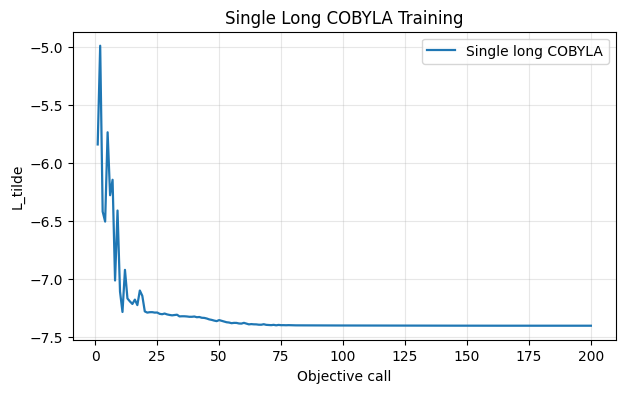

single_long calls: 200
single_long final loss: -7.403557364836534


In [12]:
# Objective trajectory plot for single_long
calls_single = np.arange(1, len(single_loss_history) + 1)
plt.figure(figsize=(7, 4))
plt.plot(calls_single, single_loss_history, linewidth=1.6, label="Single long COBYLA")
plt.xlabel("Objective call")
plt.ylabel("L_tilde")
plt.title("Single Long COBYLA Training")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("single_long calls:", len(single_loss_history))
print("single_long final loss:", schedule_results["single_long"]["final_loss"])


## 10) Build Final State from Trained Parameters


In [13]:
qc_final = QuantumCircuit(num_qubits)
theta_bind = {p: float(v) for p, v in zip(theta_params, best_theta)}
bound_ansatz = ansatz.assign_parameters(theta_bind, inplace=False)
qc_final.compose(bound_ansatz, inplace=True)

if statevector_backend is None:
    trained_state = np.asarray(Statevector.from_instruction(qc_final).data, dtype=complex)
else:
    qc_final_sim = qc_final.copy()
    if hasattr(qc_final_sim, "save_statevector"):
        qc_final_sim.save_statevector()
    result_final = statevector_backend.run(qc_final_sim).result()
    sv_data_final = None
    try:
        data_final = result_final.data(0)
        sv_data_final = data_final.get("statevector")
        if sv_data_final is None:
            sv_data_final = data_final.get("final_statevector")
    except Exception:
        sv_data_final = None
    if sv_data_final is None:
        sv_data_final = result_final.get_statevector(qc_final_sim)
    trained_state = np.asarray(sv_data_final, dtype=complex)

trained_state = trained_state / np.linalg.norm(trained_state)
print("trained_state norm:", np.linalg.norm(trained_state))
print("padding probability mass:", float(np.sum(np.abs(trained_state[n_features:]) ** 2)))


trained_state norm: 1.0
padding probability mass: 0.0


## 11) Compare with Closed-Form MAP Direction


In [14]:
sigma_inv = np.linalg.inv(Sigma0_matrix)
gram = X.T @ X + float(V) * sigma_inv
rhs = X.T @ y + float(V) * (sigma_inv @ m0)
w_star = np.linalg.solve(gram, rhs)

w_star_norm = float(np.linalg.norm(w_star))
if w_star_norm <= 0.0:
    raise RuntimeError("Closed-form solution has zero norm; cannot compute directional metrics.")

w_dir = w_star / w_star_norm
w_dir_pad = np.pad(w_dir, (0, state_dim - n_features), mode="constant")
w_dir_pad = w_dir_pad / np.linalg.norm(w_dir_pad)

overlap = np.vdot(w_dir_pad, trained_state)
phase = np.exp(-1j * np.angle(overlap))
aligned_state = trained_state * phase

fidelity = float(np.abs(np.vdot(w_dir_pad, trained_state)) ** 2)
cosine_state = float(np.real(np.vdot(w_dir_pad, aligned_state)))

# Build feature direction phi from trained_state (script-style phase gauge: pivot amplitude made real)
feature_state = np.asarray(trained_state[:n_features], dtype=complex).reshape(-1)
if feature_state.size != int(n_features):
    raise ValueError("n_features exceeds trained_state dimension.")

feature_norm = float(np.linalg.norm(feature_state))
if feature_norm > 0.0:
    pivot = int(np.argmax(np.abs(feature_state)))
    phase_phi = np.exp(-1j * np.angle(feature_state[pivot]))
    aligned_feature = feature_state * phase_phi
    feature_real = np.real_if_close(aligned_feature, tol=1000)
    if np.iscomplexobj(feature_real):
        feature_real = np.real(aligned_feature)
    feature_vec = np.asarray(feature_real, dtype=float).reshape(-1)
    feature_vec_norm = float(np.linalg.norm(feature_vec))
    if feature_vec_norm > 0.0:
        feature_dir = feature_vec / feature_vec_norm
    else:
        feature_dir = np.zeros_like(w_star)
else:
    feature_dir = np.zeros_like(w_star)

# t* from final objective snapshot: t* = (c* + e*) / (a* + d*)
snapshot = None
if "single_snapshot" in globals():
    snapshot = single_snapshot
elif "schedule_results" in globals() and "single_long" in schedule_results:
    snapshot = schedule_results["single_long"].get("snapshot", None)

if snapshot is None:
    raise RuntimeError("Could not find final objective snapshot (single_snapshot). Run training cell first.")

a_star = float(snapshot.get("a_hat", np.nan))
c_star = float(snapshot.get("c_hat", np.nan))
d_star = float(snapshot.get("d_hat", np.nan))
e_star = float(snapshot.get("e_hat", np.nan))

denom_star = a_star + d_star
numer_star = c_star + e_star
if np.isfinite(denom_star) and np.isfinite(numer_star) and abs(denom_star) > eps:
    t_star = float(numer_star / denom_star)
else:
    t_star = float("nan")

if np.isfinite(t_star) and float(np.linalg.norm(feature_dir)) > 0.0:
    reconstructed_w = float(t_star) * feature_dir
else:
    reconstructed_w = np.full_like(w_star, np.nan, dtype=float)


def signed_cosine(u, v):
    u = np.asarray(u, dtype=float).reshape(-1)
    v = np.asarray(v, dtype=float).reshape(-1)
    nu = float(np.linalg.norm(u))
    nv = float(np.linalg.norm(v))
    if nu <= 0.0 or nv <= 0.0:
        return float("nan")
    return float(np.dot(u, v) / (nu * nv))

feature_cosine = signed_cosine(feature_dir, w_dir)
reconstructed_cosine = signed_cosine(reconstructed_w, w_star)

if np.all(np.isfinite(reconstructed_w)):
    relative_l2 = float(np.linalg.norm(reconstructed_w - w_star) / w_star_norm)
else:
    relative_l2 = float("nan")

print("fidelity:", fidelity)
print("state cosine:", cosine_state)
print("t_star:", t_star)
print("feature cosine (phi vs w_star direction):", feature_cosine)
print("reconstructed cosine (reconstructed_w vs w_star):", reconstructed_cosine)
print("relative L2:", relative_l2)



fidelity: 0.9999050106990129
state cosine: 0.999952504221582
t_star: 3.2152868987627956
feature cosine (phi vs w_star direction): 0.9999525042215821
reconstructed cosine (reconstructed_w vs w_star): 0.9999525042215823
relative L2: 0.009748728848764276


## 12) Repeated Seed Experiment (Final Metrics Only)

Runs `num_seeds` independent synthetic datasets (new data per seed with current `N`, `D`),
fits closed-form MAP and VQBR, reports final per-seed metrics, summarizes with mean ± std,
and stores all artifacts (JSON/CSV/log/config) to disk.



In [15]:
import csv
import json
import time
from datetime import datetime, timezone
from pathlib import Path
from types import SimpleNamespace

import numpy as np
from scipy.optimize import minimize
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Statevector, Operator, SparsePauliOp

try:
    from qiskit.circuit.library import efficient_su2
    _HAS_EFFICIENT_SU2_LOCAL = True
except Exception:
    from qiskit.circuit.library import EfficientSU2
    _HAS_EFFICIENT_SU2_LOCAL = False

try:
    from qiskit_aer import AerSimulator
except Exception:
    AerSimulator = None


ROOT_DIR = Path.cwd().resolve()
if not (ROOT_DIR / "src").exists() and (ROOT_DIR.parent / "src").exists():
    ROOT_DIR = ROOT_DIR.parent

EPS_LOCAL = 1e-12
LOG_RATIO_FORMULA = "log(a_hat + d_hat + eps) - log((c_hat + e_hat)^2 + eps)"


def _safe_cosine(a, b, eps=EPS_LOCAL):
    a = np.asarray(a, dtype=float).reshape(-1)
    b = np.asarray(b, dtype=float).reshape(-1)
    na = float(np.linalg.norm(a))
    nb = float(np.linalg.norm(b))
    if na <= eps and nb <= eps:
        return 1.0
    if na <= eps or nb <= eps:
        return 0.0
    return float(np.dot(a, b) / (na * nb))


def _rmse(y_true, y_pred):
    err = np.asarray(y_pred, dtype=float).reshape(-1) - np.asarray(y_true, dtype=float).reshape(-1)
    return float(np.sqrt(max(float(np.mean(err * err)), 0.0)))


def _r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    if ss_tot <= EPS_LOCAL:
        return 1.0 if ss_res <= EPS_LOCAL else 0.0
    return float(1.0 - (ss_res / ss_tot))


def _split_dataset_indices(n_samples, prior_ratio, train_ratio, test_ratio, seed):
    ratio_sum = float(prior_ratio + train_ratio + test_ratio)
    if not np.isclose(ratio_sum, 1.0, atol=1e-12):
        raise ValueError(f"Split ratios must sum to 1.0, got {ratio_sum:.12f}.")

    n_prior = int(np.floor(prior_ratio * n_samples))
    n_train = int(np.floor(train_ratio * n_samples))
    n_test = int(n_samples - n_prior - n_train)
    if min(n_prior, n_train, n_test) < 1:
        raise ValueError("Invalid split sizes; prior/train/test must be non-empty.")

    perm = np.random.default_rng(int(seed)).permutation(n_samples)
    return {
        "prior": perm[:n_prior],
        "train": perm[n_prior : n_prior + n_train],
        "test": perm[n_prior + n_train :],
    }


def _ridge_solution(Xb, yb, ridge):
    Xb = np.asarray(Xb, dtype=float)
    yb = np.asarray(yb, dtype=float).reshape(-1)
    d = int(Xb.shape[1])
    gram = Xb.T @ Xb + float(ridge) * np.eye(d, dtype=float)
    rhs = Xb.T @ yb
    return np.linalg.solve(gram, rhs)


def _estimate_prior(X_prior, y_prior, *, seed, bootstrap_samples, ridge, sigma_floor, v_floor):
    X_prior = np.asarray(X_prior, dtype=float)
    y_prior = np.asarray(y_prior, dtype=float).reshape(-1)
    d = int(X_prior.shape[1])

    if int(bootstrap_samples) <= 0:
        raise ValueError("bootstrap_samples must be positive.")

    rng = np.random.default_rng(int(seed) + 77_777)
    weights = np.zeros((int(bootstrap_samples), d), dtype=float)
    for i in range(int(bootstrap_samples)):
        idx = rng.integers(0, X_prior.shape[0], size=X_prior.shape[0])
        weights[i] = _ridge_solution(X_prior[idx], y_prior[idx], ridge=ridge)

    m0_est = np.mean(weights, axis=0)
    sigma_diag = np.var(weights, axis=0, ddof=0)
    sigma_diag = np.maximum(sigma_diag, float(sigma_floor))
    Sigma0_est = np.diag(sigma_diag)

    prior_fit_mse = float(np.mean((X_prior @ m0_est - y_prior) ** 2))
    V_est = max(prior_fit_mse, float(v_floor))
    return m0_est, Sigma0_est, float(V_est), {
        "prior_fit_mse": float(prior_fit_mse),
        "mean_sigma0_diag": float(np.mean(sigma_diag)),
    }


def _snapshot_objective(snapshot):
    val = float(getattr(snapshot, "batch_L_tilde", np.nan))
    if not np.isfinite(val):
        val = float(getattr(snapshot, "L_tilde", np.nan))
    return val


def _select_snapshot_for_solution(history, target_objective=None):
    if not history:
        return None
    target = float(target_objective) if target_objective is not None else float("nan")
    candidates = []
    for snapshot in history:
        obj = _snapshot_objective(snapshot)
        a_hat = float(getattr(snapshot, "a_hat", np.nan))
        c_hat = float(getattr(snapshot, "c_hat", np.nan))
        d_hat = float(getattr(snapshot, "d_hat", np.nan))
        e_hat = float(getattr(snapshot, "e_hat", np.nan))
        if np.isfinite(obj) and np.isfinite(a_hat) and np.isfinite(c_hat) and np.isfinite(d_hat) and np.isfinite(e_hat):
            candidates.append((snapshot, float(obj)))

    if candidates:
        if np.isfinite(target):
            return min(candidates, key=lambda item: abs(item[1] - target))[0]
        return min(candidates, key=lambda item: item[1])[0]

    return history[-1]


def _state_to_feature_direction(state, n_features):
    state = np.asarray(state, dtype=complex).reshape(-1)
    feature_state = state[: int(n_features)]
    if feature_state.size != int(n_features):
        raise ValueError("n_features exceeds state dimension.")
    if feature_state.size == 0:
        return np.zeros(0, dtype=float)

    feature_norm = float(np.linalg.norm(feature_state))
    if feature_norm <= EPS_LOCAL:
        return np.zeros(int(n_features), dtype=float)

    pivot = int(np.argmax(np.abs(feature_state)))
    phase = np.exp(-1j * np.angle(feature_state[pivot]))
    aligned = feature_state * phase
    direction_real = np.real_if_close(aligned, tol=1000)
    if np.iscomplexobj(direction_real):
        direction_real = np.real(aligned)

    direction = np.asarray(direction_real, dtype=float).reshape(-1)
    direction_norm = float(np.linalg.norm(direction))
    if direction_norm <= EPS_LOCAL:
        return np.zeros(int(n_features), dtype=float)
    return direction / direction_norm


def _normalized_closed_form_state(w_closed):
    w = np.asarray(w_closed, dtype=complex).reshape(-1)
    target_dim = 2 ** int(np.ceil(np.log2(max(1, w.size))))
    if w.size != target_dim:
        w = np.pad(w, (0, target_dim - w.size), mode="constant")
    nw = float(np.linalg.norm(w))
    if nw <= EPS_LOCAL:
        out = np.zeros_like(w, dtype=complex)
        out[0] = 1.0 + 0.0j
        return out
    return w / nw


def _reconstruct_weights(phi, snapshot):
    phi = np.asarray(phi, dtype=float).reshape(-1)
    if snapshot is None:
        return float("nan"), np.full(phi.shape, np.nan, dtype=float), {}
    a_hat = float(getattr(snapshot, "a_hat", np.nan))
    c_hat = float(getattr(snapshot, "c_hat", np.nan))
    d_hat = float(getattr(snapshot, "d_hat", np.nan))
    e_hat = float(getattr(snapshot, "e_hat", np.nan))
    denom = a_hat + d_hat
    numer = c_hat + e_hat
    if not np.isfinite(denom) or not np.isfinite(numer) or abs(denom) <= EPS_LOCAL:
        return float("nan"), np.full(phi.shape, np.nan, dtype=float), {
            "a_hat": a_hat, "c_hat": c_hat, "d_hat": d_hat, "e_hat": e_hat,
            "numerator": numer, "denominator": denom,
        }
    t_hat = float(numer / denom)
    return t_hat, float(t_hat) * phi, {
        "a_hat": a_hat, "c_hat": c_hat, "d_hat": d_hat, "e_hat": e_hat,
        "numerator": numer, "denominator": denom,
    }


def _evaluate_metrics(X_train, y_train, X_test, y_test, w):
    w = np.asarray(w, dtype=float).reshape(-1)
    if w.size == 0 or not np.all(np.isfinite(w)):
        return {
            "train_rmse": float("nan"),
            "test_rmse": float("nan"),
            "train_r2": float("nan"),
            "test_r2": float("nan"),
        }
    train_pred = np.asarray(X_train, dtype=float) @ w
    test_pred = np.asarray(X_test, dtype=float) @ w
    return {
        "train_rmse": _rmse(y_train, train_pred),
        "test_rmse": _rmse(y_test, test_pred),
        "train_r2": _r2_score(y_train, train_pred),
        "test_r2": _r2_score(y_test, test_pred),
    }


def _mean_std(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return {"mean": float("nan"), "std": float("nan"), "n_valid": 0}
    return {"mean": float(np.mean(arr)), "std": float(np.std(arr, ddof=0)), "n_valid": int(arr.size)}


def _fmt(stats, sci=False):
    m = float(stats.get("mean", np.nan))
    s = float(stats.get("std", np.nan))
    if not np.isfinite(m) or not np.isfinite(s):
        return "nan +/- nan"
    return f"{m:.6e} +/- {s:.6e}" if sci else f"{m:.6f} +/- {s:.6f}"


def _pad_to_pow2(vec):
    vec = np.asarray(vec)
    if vec.ndim != 1:
        raise ValueError("Expected a 1D vector.")
    if vec.size == 0:
        raise ValueError("Vector must not be empty.")
    n = int(np.ceil(np.log2(vec.size)))
    m = 2 ** n
    if m == vec.size:
        return vec.copy()
    return np.pad(vec, (0, m - vec.size), mode="constant")


def _build_state_prep_gate(vec, label):
    vec = np.asarray(vec, dtype=complex).reshape(-1)
    vec = _pad_to_pow2(vec)
    norm = float(np.linalg.norm(vec))
    if norm <= 0.0:
        raise ValueError("State preparation vector norm must be non-zero.")
    vec = vec / norm
    prep = StatePreparation(vec)
    if hasattr(prep, "to_gate"):
        return prep.to_gate(label=label)
    return prep


def _select_statevector_backend(*, prefer_gpu, require_gpu):
    backend = None
    simulator_device = "CPU"
    simulator_backend = "statevector_cpu"
    simulator_reason = "Using CPU statevector simulator."

    if not prefer_gpu:
        simulator_reason = "Using CPU statevector simulator (prefer_gpu=False)."
        if require_gpu:
            raise RuntimeError("GPU execution was required but prefer_gpu=False.")
        return backend, simulator_backend, simulator_device, simulator_reason

    if AerSimulator is None:
        simulator_reason = "Using CPU statevector simulator (qiskit-aer unavailable)."
        if require_gpu:
            raise RuntimeError("GPU execution was required but qiskit-aer is unavailable.")
        return backend, simulator_backend, simulator_device, simulator_reason

    available_devices = set()
    if hasattr(AerSimulator, "available_devices"):
        try:
            available_devices = {str(d).strip().upper() for d in AerSimulator.available_devices()}
        except Exception:
            available_devices = set()
    if not available_devices:
        try:
            available_devices = {str(d).strip().upper() for d in AerSimulator().available_devices()}
        except Exception:
            available_devices = set()

    if available_devices and "GPU" not in available_devices:
        simulator_reason = "Using CPU statevector simulator (GPU unavailable)."
        if require_gpu:
            raise RuntimeError("GPU execution was required but Aer reports no GPU device.")
        return backend, simulator_backend, simulator_device, simulator_reason

    try:
        backend = AerSimulator(method="statevector", device="GPU")
        simulator_device = "GPU"
        simulator_backend = "AerSimulator(statevector,GPU)"
        simulator_reason = "Using AerSimulator(method='statevector', device='GPU')."
    except Exception as exc:
        simulator_reason = "Using CPU statevector simulator (Aer GPU init failed)."
        backend = None
        if require_gpu:
            raise RuntimeError("GPU execution was required but Aer GPU initialization failed.") from exc

    return backend, simulator_backend, simulator_device, simulator_reason


def _simulate_statevector(qc, *, statevector_backend, require_gpu):
    if statevector_backend is None:
        return np.asarray(Statevector.from_instruction(qc).data, dtype=complex)

    try:
        sim_qc = qc.copy()
        if hasattr(sim_qc, "save_statevector"):
            sim_qc.save_statevector()
        result = statevector_backend.run(sim_qc).result()
        state = None
        try:
            data = result.data(0)
            state = data.get("statevector")
            if state is None:
                state = data.get("final_statevector")
        except Exception:
            state = None
        if state is None:
            state = result.get_statevector(sim_qc)
        return np.asarray(state, dtype=complex)
    except Exception as exc:
        if require_gpu:
            raise RuntimeError("GPU execution failed and require_gpu=True.") from exc
        return np.asarray(Statevector.from_instruction(qc).data, dtype=complex)


def _fit_vqbr_notebook(
    X,
    y,
    m0,
    Sigma0,
    V,
    *,
    shots,
    use_shot_noise,
    reps,
    su2_gates,
    entanglement,
    optimizer,
    maxiter,
    cobyla_tol,
    loss,
    prefer_gpu,
    require_gpu,
    random_state,
    eps,
):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    m0 = np.asarray(m0, dtype=float).reshape(-1)
    Sigma0 = np.asarray(Sigma0, dtype=float)
    V = float(V)

    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape={X.shape}.")
    n_samples, n_features = X.shape
    if y.shape[0] != n_samples:
        raise ValueError(f"y must have length {n_samples}, got {y.shape[0]}.")
    if m0.shape[0] != n_features:
        raise ValueError(f"m0 must have length {n_features}, got {m0.shape[0]}.")

    if Sigma0.ndim == 1:
        if Sigma0.shape[0] != n_features:
            raise ValueError(f"Sigma0 must have length {n_features}, got {Sigma0.shape[0]}.")
        if np.any(Sigma0 <= 0.0):
            raise ValueError("All entries of 1D Sigma0 must be positive.")
        Sigma0_matrix = np.diag(Sigma0.copy())
    elif Sigma0.ndim == 2:
        if Sigma0.shape != (n_features, n_features):
            raise ValueError(f"Sigma0 must be ({n_features}, {n_features}), got {Sigma0.shape}.")
        if not np.allclose(Sigma0, Sigma0.T, atol=1e-12):
            raise ValueError("Sigma0 must be symmetric.")
        np.linalg.cholesky(Sigma0)
        Sigma0_matrix = Sigma0.copy()
    else:
        raise ValueError("Sigma0 must be either 1D diagonal or 2D matrix.")

    if V < 0.0:
        raise ValueError("V must be non-negative.")

    num_qubits = int(np.ceil(np.log2(n_features)))
    state_dim = 2 ** num_qubits

    statevector_backend, simulator_backend, simulator_device, simulator_reason = _select_statevector_backend(
        prefer_gpu=bool(prefer_gpu),
        require_gpu=bool(require_gpu),
    )

    eye = np.eye(Sigma0_matrix.shape[0], dtype=float)
    precision = np.linalg.solve(Sigma0_matrix, eye)
    precision = 0.5 * (precision + precision.T)

    precision_diag = np.diag(precision)
    off_diag = precision - np.diag(precision_diag)
    precision_is_diagonal = bool(np.allclose(off_diag, 0.0, atol=1e-12))
    precision_diag_padded = _pad_to_pow2(precision_diag)

    row_norms = np.linalg.norm(X, axis=1)
    if np.any(row_norms <= 0.0):
        raise ValueError("Each row in X must have non-zero norm for normalized state encoding.")

    Uxi_gates = [_build_state_prep_gate(X[i], label=f"Ux_{i}") for i in range(n_samples)]

    c_vec = float(V) * (precision @ m0)
    c_norm = float(np.linalg.norm(c_vec))
    Uc_gate = _build_state_prep_gate(c_vec, label="Uc") if c_norm > 0.0 else None

    if _HAS_EFFICIENT_SU2_LOCAL:
        ansatz = efficient_su2(
            num_qubits,
            su2_gates=list(su2_gates),
            entanglement=str(entanglement),
            reps=int(reps),
        )
    else:
        ansatz = EfficientSU2(
            num_qubits,
            su2_gates=list(su2_gates),
            entanglement=str(entanglement),
            reps=int(reps),
        )

    theta_params = list(ansatz.parameters)
    rng = np.random.default_rng(int(random_state))
    theta_init = 0.01 * rng.standard_normal(len(theta_params))

    sampling_backend = None
    if bool(use_shot_noise):
        if AerSimulator is None:
            raise RuntimeError("qiskit-aer is required for use_shot_noise=True.")
        sampling_backend = AerSimulator()

    M_pad = np.zeros((state_dim, state_dim), dtype=complex)
    M_pad[:n_features, :n_features] = float(V) * precision

    dense_pauli_terms = None
    if (not precision_is_diagonal) and bool(use_shot_noise):
        dense_pauli = SparsePauliOp.from_operator(Operator(M_pad)).simplify(atol=1e-12)
        dense_pauli_terms = []
        for label, coeff in zip(dense_pauli.paulis.to_labels(), dense_pauli.coeffs):
            if abs(coeff) > 1e-12:
                dense_pauli_terms.append((label, complex(coeff)))

    def run_shot_counts(qc):
        if sampling_backend is None:
            raise RuntimeError("Sampling backend is unavailable.")
        qc_meas = qc.copy()
        qc_meas.measure_all()
        compiled = transpile(qc_meas, sampling_backend, optimization_level=0)
        result = sampling_backend.run(compiled, shots=int(shots)).result()
        counts = result.get_counts(compiled)
        if isinstance(counts, list):
            counts = counts[0]
        total = int(sum(counts.values()))
        if total <= 0:
            raise RuntimeError("No counts returned from sampler backend.")
        return counts, total

    def estimate_overlap(theta_vec, Uv_gate):
        qc = QuantumCircuit(1 + num_qubits)
        anc = 0
        work = list(range(1, 1 + num_qubits))

        qc.h(anc)
        qc.x(anc)
        qc.append(Uv_gate.control(1), [anc] + work)
        qc.x(anc)

        theta_bind = {p: float(v) for p, v in zip(theta_params, np.asarray(theta_vec, dtype=float).reshape(-1))}
        bound_ansatz = ansatz.assign_parameters(theta_bind, inplace=False)
        qc.append(bound_ansatz.to_gate(label="Utheta").control(1), [anc] + work)
        qc.h(anc)

        if bool(use_shot_noise):
            counts, total = run_shot_counts(qc)
            n0 = sum(cnt for bitstr, cnt in counts.items() if bitstr[-1] == "0")
            p0 = float(n0) / float(total)
        else:
            state = _simulate_statevector(
                qc,
                statevector_backend=statevector_backend,
                require_gpu=bool(require_gpu),
            )
            p0 = float(np.sum(np.abs(state[::2]) ** 2))
            p0 = float(np.clip(p0, 0.0, 1.0))

        s_hat = 2.0 * p0 - 1.0
        return float(np.clip(s_hat, -1.0, 1.0))

    def estimate_d_hat(theta_vec):
        theta_bind = {p: float(v) for p, v in zip(theta_params, np.asarray(theta_vec, dtype=float).reshape(-1))}
        bound_ansatz = ansatz.assign_parameters(theta_bind, inplace=False)

        qc = QuantumCircuit(num_qubits)
        qc.compose(bound_ansatz, inplace=True)

        if precision_is_diagonal:
            if bool(use_shot_noise):
                counts, total = run_shot_counts(qc)
                d_hat_local = 0.0
                for bitstr, cnt in counts.items():
                    basis_index = int(bitstr, 2)
                    d_hat_local += float(precision_diag_padded[basis_index]) * float(cnt) / float(total)
                return float(V * d_hat_local)

            state = _simulate_statevector(
                qc,
                statevector_backend=statevector_backend,
                require_gpu=bool(require_gpu),
            )
            probs = np.abs(state) ** 2
            probs = probs / np.sum(probs)
            return float(V * np.dot(precision_diag_padded, probs))

        if not bool(use_shot_noise):
            state = _simulate_statevector(
                qc,
                statevector_backend=statevector_backend,
                require_gpu=bool(require_gpu),
            )
            return float(np.real(np.vdot(state, M_pad @ state)))

        if dense_pauli_terms is None:
            raise RuntimeError("Dense precision shot path requires Pauli decomposition terms.")

        d_hat_local = 0.0
        for label, coeff in dense_pauli_terms:
            qc_term = QuantumCircuit(num_qubits)
            qc_term.compose(bound_ansatz, inplace=True)

            for q in range(num_qubits):
                pauli_char = label[num_qubits - 1 - q]
                if pauli_char == "X":
                    qc_term.h(q)
                elif pauli_char == "Y":
                    qc_term.sdg(q)
                    qc_term.h(q)

            counts, total = run_shot_counts(qc_term)
            mu_hat = 0.0
            for bitstr, cnt in counts.items():
                parity = 1.0
                for q in range(num_qubits):
                    pauli_char = label[num_qubits - 1 - q]
                    if pauli_char == "I":
                        continue
                    if bitstr[-1 - q] == "1":
                        parity *= -1.0
                mu_hat += parity * float(cnt) / float(total)
            d_hat_local += float(np.real(coeff)) * mu_hat

        return float(d_hat_local)

    def compute_batch_loss(theta_vec, batch_indices, scale_to_full=True):
        batch_indices = np.asarray(batch_indices, dtype=int).reshape(-1)
        if batch_indices.size == 0:
            raise ValueError("batch_indices must not be empty.")

        s = np.array([estimate_overlap(theta_vec, Uxi_gates[i]) for i in batch_indices], dtype=float)
        r = row_norms[batch_indices]
        yb = y[batch_indices]

        scale = float(n_samples / batch_indices.size) if scale_to_full else 1.0
        a_hat = float(scale * np.sum((r * s) ** 2))
        c_hat = float(scale * np.sum(yb * (r * s)))

        h_hat = 0.0
        e_hat = 0.0
        if Uc_gate is not None and c_norm > 0.0:
            h_hat = estimate_overlap(theta_vec, Uc_gate)
            e_hat = float(c_norm * h_hat)

        d_hat = estimate_d_hat(theta_vec)

        denom = a_hat + d_hat + float(eps)
        numerator = c_hat + e_hat
        if str(loss).strip().lower() == "log_ratio":
            L_tilde = float(np.log(denom) - np.log((numerator * numerator) + float(eps)))
        else:
            L_tilde = float(-((numerator * numerator) / denom))

        snapshot = SimpleNamespace(
            L_tilde=float(L_tilde),
            batch_L_tilde=float(L_tilde),
            full_L_tilde=float(L_tilde),
            a_hat=float(a_hat),
            c_hat=float(c_hat),
            d_hat=float(d_hat),
            e_hat=float(e_hat),
            h_hat=float(h_hat),
            batch_indices=batch_indices.copy(),
            epoch=0,
            batch_position=0,
        )
        return float(L_tilde), snapshot

    full_indices = np.arange(n_samples, dtype=int)
    history = []

    def objective(theta_vec):
        lval, snapshot = compute_batch_loss(theta_vec, full_indices, scale_to_full=False)
        history.append(snapshot)
        return float(lval)

    options = {"maxiter": int(maxiter)}
    optimizer_name = str(optimizer).upper()
    if optimizer_name == "COBYLA":
        options["tol"] = float(cobyla_tol)
    elif optimizer_name == "L-BFGS-B":
        options["ftol"] = float(globals().get("lbfgsb_ftol", 1e-12))
        options["gtol"] = float(globals().get("lbfgsb_gtol", 1e-8))
    elif optimizer_name == "CG":
        options["gtol"] = float(globals().get("cg_gtol", 1e-8))

    result = minimize(
        objective,
        theta_init.copy(),
        method=str(optimizer),
        options=options,
    )

    best_theta = np.asarray(result.x, dtype=float)
    theta_bind = {p: float(v) for p, v in zip(theta_params, best_theta)}
    bound_ansatz = ansatz.assign_parameters(theta_bind, inplace=False)
    qc_final = QuantumCircuit(num_qubits)
    qc_final.compose(bound_ansatz, inplace=True)

    trained_state = _simulate_statevector(
        qc_final,
        statevector_backend=statevector_backend,
        require_gpu=bool(require_gpu),
    )
    trained_state = np.asarray(trained_state, dtype=complex).reshape(-1)
    trained_state = trained_state / np.linalg.norm(trained_state)

    final_full_loss, final_full_snapshot = compute_batch_loss(
        best_theta,
        full_indices,
        scale_to_full=False,
    )

    overlaps_final = np.array(
        [estimate_overlap(best_theta, Uxi_gates[i]) for i in range(n_samples)],
        dtype=float,
    )
    z_final = row_norms * overlaps_final
    phi_overlap, *_ = np.linalg.lstsq(np.asarray(X, dtype=float), z_final, rcond=None)
    phi_overlap = np.asarray(phi_overlap, dtype=float).reshape(-1)
    phi_overlap_norm = float(np.linalg.norm(phi_overlap))
    if phi_overlap_norm > EPS_LOCAL:
        phi_overlap = phi_overlap / phi_overlap_norm
    else:
        phi_overlap = np.zeros(n_features, dtype=float)

    return {
        "state": trained_state,
        "history": history,
        "result": result,
        "simulator_backend": str(simulator_backend),
        "simulator_device": str(simulator_device),
        "simulator_reason": str(simulator_reason),
        "final_snapshot": final_full_snapshot,
        "final_snapshot_loss": float(final_full_loss),
        "phi_overlap": phi_overlap,
    }


# Experiment config (seed-repeat; new synthetic data per seed)
num_seeds = int(globals().get("num_seeds", 20))
seed_offset = int(globals().get("seed_offset", 0))
seed_list = [seed_offset + i for i in range(num_seeds)]

n_samples_exp = int(globals().get("n_samples_total", 200))
n_features_exp = int(globals().get("n_features", 8))
noise_std_exp = float(globals().get("noise_std", 0.1))
w_true_std_exp = float(globals().get("w_true_std", 1.0))

prior_ratio_exp = float(globals().get("prior_ratio", 0.2))
train_ratio_exp = float(globals().get("train_ratio", 0.6))
test_ratio_exp = float(globals().get("test_ratio", 0.2))

bootstrap_samples_exp = int(globals().get("bootstrap_samples", 64))
prior_ridge_exp = float(globals().get("prior_ridge", 1e-6))
prior_sigma_floor_exp = float(globals().get("prior_sigma_floor", 1e-4))
v_floor_exp = float(globals().get("v_floor", 1e-8))

optimizer_exp = str(globals().get("optimizer", "COBYLA"))
maxiter_exp = int(globals().get("max_optimizer_iterations", 300))
cobyla_tol_exp = float(globals().get("cobyla_tol", 1e-8))
reps_exp = int(globals().get("reps", 2))
su2_gates_exp = tuple(globals().get("su2_gates", ("ry", "x")))
entanglement_exp = str(globals().get("entanglement", "linear"))
loss_exp = str(globals().get("loss", "log_ratio"))
shots_exp = int(globals().get("shots", 10000))
use_shot_noise_exp = bool(globals().get("use_shot_noise", False))
prefer_gpu_exp = bool(globals().get("prefer_gpu", True))
require_gpu_exp = bool(globals().get("require_gpu", False))
eps_exp = float(globals().get("eps", 1e-12))

run_tag = (
    f"notebook_seed_repeat_N{n_samples_exp}_D{n_features_exp}_"
    f"seeds{num_seeds}_maxiter{maxiter_exp}_"
    f"{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
out_dir = ROOT_DIR / "results" / "synthetic"
out_dir.mkdir(parents=True, exist_ok=True)

results_json_path = out_dir / f"{run_tag}_results.json"
per_seed_csv_path = out_dir / f"{run_tag}_per_seed.csv"
summary_csv_path = out_dir / f"{run_tag}_summary.csv"
run_config_path = out_dir / f"{run_tag}_run_config.json"
run_log_path = out_dir / f"{run_tag}_run.log"

log_lines = []

def log(msg=""):
    text = str(msg)
    print(text, flush=True)
    log_lines.append(text)


log(f"Console log file: {run_log_path}")
log("=== Synthetic Seed-Repeat Experiment (Notebook Built-In Impl) ===")
log(
    f"N={n_samples_exp}, D={n_features_exp}, noise_std={noise_std_exp:.6f}, w_true_std={w_true_std_exp:.6f}"
)
log(
    f"Split ratios: prior={prior_ratio_exp:.3f}, train={train_ratio_exp:.3f}, test={test_ratio_exp:.3f}"
)
log(f"Seeds ({len(seed_list)}): {', '.join(str(s) for s in seed_list)}")
log(
    f"VQBR config: optimizer={optimizer_exp}, reps={reps_exp}, entanglement={entanglement_exp}, "
    f"maxiter={maxiter_exp}, cobyla_tol={cobyla_tol_exp:.3e}, "
    f"loss={loss_exp}, use_shot_noise={use_shot_noise_exp}"
)
if str(loss_exp).strip().lower() == "log_ratio":
    log(f"VQBR log_ratio formula: {LOG_RATIO_FORMULA}")

experiment_start = time.perf_counter()
per_seed_results = []

for seed_idx, seed_val in enumerate(seed_list, start=1):
    log("")
    log(f"[seed={seed_val}] ({seed_idx}/{len(seed_list)})")
    seed_start = time.perf_counter()

    rng_seed = np.random.default_rng(int(seed_val))
    X_full = rng_seed.standard_normal(size=(n_samples_exp, n_features_exp))
    w_true_seed = rng_seed.normal(0.0, w_true_std_exp, size=n_features_exp)
    y_full = X_full @ w_true_seed + rng_seed.normal(0.0, noise_std_exp, size=n_samples_exp)

    split = _split_dataset_indices(
        n_samples=n_samples_exp,
        prior_ratio=prior_ratio_exp,
        train_ratio=train_ratio_exp,
        test_ratio=test_ratio_exp,
        seed=int(seed_val),
    )
    X_prior, y_prior = X_full[split["prior"]], y_full[split["prior"]]
    X_train, y_train = X_full[split["train"]], y_full[split["train"]]
    X_test, y_test = X_full[split["test"]], y_full[split["test"]]

    prior_start = time.perf_counter()
    m0_seed, Sigma0_seed, V_seed, prior_info = _estimate_prior(
        X_prior,
        y_prior,
        seed=int(seed_val),
        bootstrap_samples=bootstrap_samples_exp,
        ridge=prior_ridge_exp,
        sigma_floor=prior_sigma_floor_exp,
        v_floor=v_floor_exp,
    )
    prior_runtime = float(time.perf_counter() - prior_start)

    log(
        f"  prior estimate: V={V_seed:.6e}, prior_fit_mse={prior_info['prior_fit_mse']:.6e}, "
        f"mean_sigma0_diag={prior_info['mean_sigma0_diag']:.6e}"
    )

    closed_start = time.perf_counter()
    sigma_inv_seed = np.linalg.inv(Sigma0_seed)
    gram_seed = X_train.T @ X_train + float(V_seed) * sigma_inv_seed
    rhs_seed = X_train.T @ y_train + float(V_seed) * (sigma_inv_seed @ m0_seed)
    w_closed = np.linalg.solve(gram_seed, rhs_seed)
    closed_runtime = float(time.perf_counter() - closed_start)

    closed_metrics = _evaluate_metrics(X_train, y_train, X_test, y_test, w_closed)
    log(
        "  closed-form: "
        f"train_rmse={closed_metrics['train_rmse']:.6e}, test_rmse={closed_metrics['test_rmse']:.6e}, "
        f"train_R2={closed_metrics['train_r2']:.6f}, test_R2={closed_metrics['test_r2']:.6f}"
    )

    vq_start = time.perf_counter()
    fit_out = _fit_vqbr_notebook(
        X_train,
        y_train,
        m0_seed,
        Sigma0_seed,
        V_seed,
        shots=shots_exp,
        use_shot_noise=use_shot_noise_exp,
        reps=reps_exp,
        su2_gates=su2_gates_exp,
        entanglement=entanglement_exp,
        optimizer=optimizer_exp,
        maxiter=maxiter_exp,
        cobyla_tol=cobyla_tol_exp,
        loss=loss_exp,
        prefer_gpu=prefer_gpu_exp,
        require_gpu=require_gpu_exp,
        random_state=int(seed_val),
        eps=eps_exp,
    )
    vq_runtime = float(time.perf_counter() - vq_start)

    vq_state = np.asarray(fit_out["state"], dtype=complex).reshape(-1)
    history = list(fit_out["history"])
    result_obj = fit_out["result"]

    objective_history = [_snapshot_objective(s) for s in history]
    result_fun = float(getattr(result_obj, "fun", np.nan))
    final_snapshot = fit_out.get("final_snapshot", None)
    if final_snapshot is None:
        final_snapshot = _select_snapshot_for_solution(history, target_objective=result_fun)

    phi_from_overlaps = np.asarray(fit_out.get("phi_overlap", np.array([])), dtype=float).reshape(-1)
    if (
        phi_from_overlaps.size == int(n_features_exp)
        and np.all(np.isfinite(phi_from_overlaps))
        and float(np.linalg.norm(phi_from_overlaps)) > EPS_LOCAL
    ):
        phi = phi_from_overlaps / float(np.linalg.norm(phi_from_overlaps))
        phi_source = "overlap_lstsq"
    else:
        phi = _state_to_feature_direction(vq_state, n_features_exp)
        phi_source = "statevector_phase_gauge"
    t_hat, w_hat, recon_terms = _reconstruct_weights(phi, final_snapshot)
    vq_metrics = _evaluate_metrics(X_train, y_train, X_test, y_test, w_hat)

    w_closed_norm = float(np.linalg.norm(w_closed))
    w_closed_unit = w_closed / w_closed_norm if w_closed_norm > EPS_LOCAL else np.zeros_like(w_closed)

    feature_cos = _safe_cosine(phi, w_closed_unit)
    cosine = _safe_cosine(w_hat, w_closed)
    state_overlap_abs = float(np.abs(np.vdot(_normalized_closed_form_state(w_closed), vq_state)))

    finite_objectives = [x for x in objective_history if np.isfinite(x)]
    if np.isfinite(result_fun):
        final_objective = float(result_fun)
    elif finite_objectives:
        final_objective = float(np.min(finite_objectives))
    else:
        final_objective = float("nan")

    optimizer_nfev = float(getattr(result_obj, "nfev", np.nan))
    optimizer_nit = float(getattr(result_obj, "nit", np.nan))

    seed_runtime = float(time.perf_counter() - seed_start)
    runtime_info = {
        "prior_estimation": prior_runtime,
        "closed_form_fit": closed_runtime,
        "vqbr_fit": vq_runtime,
        "total": seed_runtime,
    }

    log(
        "  vqbr: "
        f"cos={cosine:.6f}, feature_cos={feature_cos:.6f}, "
        f"train_rmse={vq_metrics['train_rmse']:.6e}, test_rmse={vq_metrics['test_rmse']:.6e}, "
        f"train_R2={vq_metrics['train_r2']:.6f}, test_R2={vq_metrics['test_r2']:.6f}, t_hat={t_hat:.6e}"
    )
    log(
        "  runtime (s): "
        f"prior={runtime_info['prior_estimation']:.3f}, closed_form={runtime_info['closed_form_fit']:.3f}, "
        f"vqbr_fit={runtime_info['vqbr_fit']:.3f}, total={runtime_info['total']:.3f}"
    )

    per_seed_results.append({
        "seed": int(seed_val),
        "dataset": {
            "n_samples": int(n_samples_exp),
            "n_features": int(n_features_exp),
            "noise_std": float(noise_std_exp),
            "w_true_std": float(w_true_std_exp),
            "w_true_norm": float(np.linalg.norm(w_true_seed)),
        },
        "split_sizes": {
            "prior": int(X_prior.shape[0]),
            "train": int(X_train.shape[0]),
            "test": int(X_test.shape[0]),
        },
        "prior_estimate": {
            "V": float(V_seed),
            "m0_norm": float(np.linalg.norm(m0_seed)),
            "mean_sigma0_diag": float(np.mean(np.diag(Sigma0_seed))),
            "prior_fit_mse": float(prior_info["prior_fit_mse"]),
            "bootstrap_samples": int(bootstrap_samples_exp),
            "ridge": float(prior_ridge_exp),
            "sigma_floor": float(prior_sigma_floor_exp),
            "v_floor": float(v_floor_exp),
        },
        "runtime_seconds": runtime_info,
        "methods": {
            "closed_form": {
                "train_rmse": float(closed_metrics["train_rmse"]),
                "test_rmse": float(closed_metrics["test_rmse"]),
                "train_r2": float(closed_metrics["train_r2"]),
                "test_r2": float(closed_metrics["test_r2"]),
            },
            "vqbr": {
                "cosine_similarity": float(cosine),
                "feature_cosine_similarity": float(feature_cos),
                "state_overlap_abs": float(state_overlap_abs),
                "train_rmse": float(vq_metrics["train_rmse"]),
                "test_rmse": float(vq_metrics["test_rmse"]),
                "train_r2": float(vq_metrics["train_r2"]),
                "test_r2": float(vq_metrics["test_r2"]),
                "t_hat": float(t_hat),
                "final_objective": float(final_objective),
                "objective_evaluations": int(len(objective_history)),
                "optimizer_nfev": float(optimizer_nfev),
                "optimizer_iterations": float(optimizer_nit),
                "reconstruction_terms": recon_terms,
                "objective_history": [float(x) for x in objective_history],
                "optimizer_success": bool(getattr(result_obj, "success", False)),
                "optimizer_message": str(getattr(result_obj, "message", "")),
                "simulator_backend": str(fit_out["simulator_backend"]),
                "simulator_device": str(fit_out["simulator_device"]),
                "simulator_reason": str(fit_out["simulator_reason"]),
                "feature_direction_source": str(phi_source),
            },
        },
    })


def _collect(method_key, metric_key):
    return [float(seed_result["methods"][method_key].get(metric_key, np.nan)) for seed_result in per_seed_results]

aggregate = {
    "vqbr": {
        "cosine_similarity": _mean_std(_collect("vqbr", "cosine_similarity")),
        "feature_cosine_similarity": _mean_std(_collect("vqbr", "feature_cosine_similarity")),
        "state_overlap_abs": _mean_std(_collect("vqbr", "state_overlap_abs")),
        "train_rmse": _mean_std(_collect("vqbr", "train_rmse")),
        "test_rmse": _mean_std(_collect("vqbr", "test_rmse")),
        "train_r2": _mean_std(_collect("vqbr", "train_r2")),
        "test_r2": _mean_std(_collect("vqbr", "test_r2")),
        "t_hat": _mean_std(_collect("vqbr", "t_hat")),
        "final_objective": _mean_std(_collect("vqbr", "final_objective")),
    },
    "closed_form": {
        "train_rmse": _mean_std(_collect("closed_form", "train_rmse")),
        "test_rmse": _mean_std(_collect("closed_form", "test_rmse")),
        "train_r2": _mean_std(_collect("closed_form", "train_r2")),
        "test_r2": _mean_std(_collect("closed_form", "test_r2")),
    },
    "runtime_seconds": {
        "prior_estimation": _mean_std([float(r["runtime_seconds"].get("prior_estimation", np.nan)) for r in per_seed_results]),
        "closed_form_fit": _mean_std([float(r["runtime_seconds"].get("closed_form_fit", np.nan)) for r in per_seed_results]),
        "vqbr_fit": _mean_std([float(r["runtime_seconds"].get("vqbr_fit", np.nan)) for r in per_seed_results]),
        "total": _mean_std([float(r["runtime_seconds"].get("total", np.nan)) for r in per_seed_results]),
    },
    "iterations": {
        "vqbr_objective_evaluations": _mean_std(_collect("vqbr", "objective_evaluations")),
        "vqbr_optimizer_nfev": _mean_std(_collect("vqbr", "optimizer_nfev")),
        "vqbr_optimizer_iterations": _mean_std(_collect("vqbr", "optimizer_iterations")),
    },
}

total_runtime = float(time.perf_counter() - experiment_start)

log("")
log("=== Aggregate Results (mean +/- std over seeds) ===")
log(f"VQBR cosine:            {_fmt(aggregate['vqbr']['cosine_similarity'], sci=False)}")
log(f"VQBR feature cosine:    {_fmt(aggregate['vqbr']['feature_cosine_similarity'], sci=False)}")
log(f"VQBR train RMSE:        {_fmt(aggregate['vqbr']['train_rmse'], sci=True)}")
log(f"VQBR test RMSE:         {_fmt(aggregate['vqbr']['test_rmse'], sci=True)}")
log(f"VQBR train R^2:         {_fmt(aggregate['vqbr']['train_r2'], sci=False)}")
log(f"VQBR test R^2:          {_fmt(aggregate['vqbr']['test_r2'], sci=False)}")
log(f"Closed-form train RMSE: {_fmt(aggregate['closed_form']['train_rmse'], sci=True)}")
log(f"Closed-form test RMSE:  {_fmt(aggregate['closed_form']['test_rmse'], sci=True)}")
log(f"Closed-form train R^2:  {_fmt(aggregate['closed_form']['train_r2'], sci=False)}")
log(f"Closed-form test R^2:   {_fmt(aggregate['closed_form']['test_r2'], sci=False)}")
log(f"VQBR fit runtime (s):   {_fmt(aggregate['runtime_seconds']['vqbr_fit'], sci=True)}")
log(f"Total wall-clock runtime: {total_runtime:.3f} s")

# Per-seed CSV (method rows)
with per_seed_csv_path.open("w", encoding="utf-8", newline="") as f:
    fieldnames = [
        "seed", "method", "cosine_similarity", "feature_cosine_similarity", "state_overlap_abs",
        "train_rmse", "test_rmse", "train_r2", "test_r2", "t_hat", "final_objective",
        "objective_evaluations", "optimizer_nfev", "optimizer_iterations",
        "runtime_seconds_method", "runtime_seconds_seed_total",
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for seed_result in per_seed_results:
        seed = int(seed_result["seed"])
        runtime_seed_total = float(seed_result["runtime_seconds"].get("total", np.nan))
        runtime_vq = float(seed_result["runtime_seconds"].get("vqbr_fit", np.nan))
        runtime_cf = float(seed_result["runtime_seconds"].get("closed_form_fit", np.nan))

        vq = dict(seed_result["methods"]["vqbr"])
        writer.writerow({
            "seed": seed,
            "method": "vqbr",
            "cosine_similarity": float(vq.get("cosine_similarity", np.nan)),
            "feature_cosine_similarity": float(vq.get("feature_cosine_similarity", np.nan)),
            "state_overlap_abs": float(vq.get("state_overlap_abs", np.nan)),
            "train_rmse": float(vq.get("train_rmse", np.nan)),
            "test_rmse": float(vq.get("test_rmse", np.nan)),
            "train_r2": float(vq.get("train_r2", np.nan)),
            "test_r2": float(vq.get("test_r2", np.nan)),
            "t_hat": float(vq.get("t_hat", np.nan)),
            "final_objective": float(vq.get("final_objective", np.nan)),
            "objective_evaluations": float(vq.get("objective_evaluations", np.nan)),
            "optimizer_nfev": float(vq.get("optimizer_nfev", np.nan)),
            "optimizer_iterations": float(vq.get("optimizer_iterations", np.nan)),
            "runtime_seconds_method": float(runtime_vq),
            "runtime_seconds_seed_total": float(runtime_seed_total),
        })

        cf = dict(seed_result["methods"]["closed_form"])
        writer.writerow({
            "seed": seed,
            "method": "closed_form",
            "cosine_similarity": float("nan"),
            "feature_cosine_similarity": float("nan"),
            "state_overlap_abs": float("nan"),
            "train_rmse": float(cf.get("train_rmse", np.nan)),
            "test_rmse": float(cf.get("test_rmse", np.nan)),
            "train_r2": float(cf.get("train_r2", np.nan)),
            "test_r2": float(cf.get("test_r2", np.nan)),
            "t_hat": float("nan"),
            "final_objective": float("nan"),
            "objective_evaluations": float("nan"),
            "optimizer_nfev": float("nan"),
            "optimizer_iterations": float("nan"),
            "runtime_seconds_method": float(runtime_cf),
            "runtime_seconds_seed_total": float(runtime_seed_total),
        })

# Summary CSV
with summary_csv_path.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["category", "method", "metric", "mean", "std", "n_valid"])
    writer.writeheader()
    for method in ("vqbr", "closed_form"):
        for metric, stats in aggregate[method].items():
            writer.writerow({
                "category": "method_metric",
                "method": method,
                "metric": metric,
                "mean": float(stats.get("mean", np.nan)),
                "std": float(stats.get("std", np.nan)),
                "n_valid": int(stats.get("n_valid", 0)),
            })
    for metric, stats in aggregate["runtime_seconds"].items():
        writer.writerow({
            "category": "runtime_seconds",
            "method": "runtime",
            "metric": metric,
            "mean": float(stats.get("mean", np.nan)),
            "std": float(stats.get("std", np.nan)),
            "n_valid": int(stats.get("n_valid", 0)),
        })
    for metric, stats in aggregate["iterations"].items():
        writer.writerow({
            "category": "iterations",
            "method": "vqbr",
            "metric": metric,
            "mean": float(stats.get("mean", np.nan)),
            "std": float(stats.get("std", np.nan)),
            "n_valid": int(stats.get("n_valid", 0)),
        })

# Results JSON + run config
payload = {
    "run_utc": datetime.now(timezone.utc).isoformat(),
    "config": {
        "n_samples": int(n_samples_exp),
        "n_features": int(n_features_exp),
        "noise_std": float(noise_std_exp),
        "w_true_std": float(w_true_std_exp),
        "split_ratios": {
            "prior": float(prior_ratio_exp),
            "train": float(train_ratio_exp),
            "test": float(test_ratio_exp),
        },
        "seeds": [int(s) for s in seed_list],
        "num_seeds": int(len(seed_list)),
        "prior_estimation": {
            "bootstrap_samples": int(bootstrap_samples_exp),
            "ridge": float(prior_ridge_exp),
            "sigma_floor": float(prior_sigma_floor_exp),
            "v_floor": float(v_floor_exp),
        },
        "vqbr": {
            "implementation": "notebook_builtin",
            "optimizer": str(optimizer_exp),
            "reps": int(reps_exp),
            "su2_gates": [str(g) for g in su2_gates_exp],
            "entanglement": str(entanglement_exp),
            "maxiter": int(maxiter_exp),
            "cobyla_tol": float(cobyla_tol_exp),
            "shots": int(shots_exp),
            "use_shot_noise": bool(use_shot_noise_exp),
            "loss": str(loss_exp),
            "loss_formula": str(LOG_RATIO_FORMULA if str(loss_exp).strip().lower() == "log_ratio" else "neg_ratio"),
            "prefer_gpu": bool(prefer_gpu_exp),
            "require_gpu": bool(require_gpu_exp),
        },
    },
    "per_seed": per_seed_results,
    "aggregate": aggregate,
    "runtime_seconds_total": float(total_runtime),
    "artifacts": {
        "results_json": str(results_json_path),
        "per_seed_csv": str(per_seed_csv_path),
        "summary_csv": str(summary_csv_path),
        "run_config_json": str(run_config_path),
        "console_log": str(run_log_path),
    },
}

with results_json_path.open("w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

run_config_payload = {
    "saved_utc": datetime.now(timezone.utc).isoformat(),
    "notebook": "notebooks/vqbr_step_by_step_debug_v2_log_ratio.ipynb",
    "run_tag": run_tag,
    "resolved": payload["config"],
    "outputs": payload["artifacts"],
}
with run_config_path.open("w", encoding="utf-8") as f:
    json.dump(run_config_payload, f, indent=2)

run_log_path.write_text("\n".join(log_lines) + "\n", encoding="utf-8")

print("Saved JSON results to:", results_json_path)
print("Saved run config JSON:", run_config_path)
print("Saved per-seed metrics:", per_seed_csv_path)
print("Saved aggregate summary:", summary_csv_path)
print("Saved console log to:", run_log_path)


Console log file: /work/tiennv/VQBR/results/synthetic/notebook_seed_repeat_N200_D8_seeds20_maxiter200_20260318_063923_run.log
=== Synthetic Seed-Repeat Experiment (Notebook Built-In Impl) ===
N=200, D=8, noise_std=0.100000, w_true_std=1.000000
Split ratios: prior=0.200, train=0.600, test=0.200
Seeds (20): 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19
VQBR config: optimizer=COBYLA, reps=2, entanglement=linear, maxiter=200, cobyla_tol=1.000e-08, loss=log_ratio, use_shot_noise=False
VQBR log_ratio formula: log(a_hat + d_hat + eps) - log((c_hat + e_hat)^2 + eps)

[seed=0] (1/20)
  prior estimate: V=5.550126e-03, prior_fit_mse=5.550126e-03, mean_sigma0_diag=2.722806e-04
  closed-form: train_rmse=1.136352e-01, test_rmse=1.157044e-01, train_R2=0.998193, test_R2=0.998665
  vqbr: cos=0.999993, feature_cos=-0.999993, train_rmse=1.135914e-01, test_rmse=1.197949e-01, train_R2=0.998195, test_R2=0.998569, t_hat=-2.819403e+00
  runtime (s): prior=0.004, closed_form=0.000, vqbr_

## 13) Inspect One Overlap Circuit


In [16]:
sample_i = 0
qc_show = QuantumCircuit(1 + num_qubits)
anc = 0
work = list(range(1, 1 + num_qubits))

qc_show.h(anc)
qc_show.x(anc)
qc_show.append(Uxi_gates[sample_i].control(1), [anc] + work)
qc_show.x(anc)

theta_bind = {p: float(v) for p, v in zip(theta_params, best_theta)}
bound_ansatz = ansatz.assign_parameters(theta_bind, inplace=False)
qc_show.append(bound_ansatz.to_gate(label="Utheta").control(1), [anc] + work)
qc_show.h(anc)

print(qc_show.decompose(reps=1).draw(output="text"))


     ┌────────────┐┌──────────┐                        »
q_0: ┤ U(π/2,0,π) ├┤ U(π,0,π) ├───────────■────────────»
     └────────────┘└──────────┘┌──────────┴───────────┐»
q_1: ──────────────────────────┤ U(π/2,-5.8566,π/2,0) ├»
                               └──────────────────────┘»
q_2: ──────────────────────────────────────────────────»
                                                       »
q_3: ──────────────────────────────────────────────────»
                                                       »
«                                                                             »
«q_0: ────────────■────────────────────■──────────■──────────────■────────────»
«                 │                    │          │              │            »
«q_1: ────────────┼────────────────────┼──────────┼──────────────┼────────────»
«     ┌───────────┴───────────┐        │        ┌─┴─┐┌───────────┴───────────┐»
«q_2: ┤ U(π/2,0.99089,3π/2,0) ├────────┼────────┤ X ├┤ U(π/2,π/2,-0.33481,0) ├»
«     └

This notebook is self-contained and supports two modes:
1. Step-by-step single-run debugging of VQBR internals.
2. Repeated-seed synthetic experiments (Section 12) with per-seed final metrics,
   aggregate mean±std summaries, and saved disk artifacts (JSON/CSV/log/config).

